In [86]:
import warnings
warnings.filterwarnings('ignore')

In [87]:
import pandas as pd
import numpy as np

In [88]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [89]:
df = pd.read_csv('train.csv', usecols = ['Age', 'Fare', 'Survived'])

In [ ]:
df.dropna(inplace = True)

In [91]:
df.shape

(714, 3)

In [92]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [93]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [95]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [ ]:
clf = DecisionTreeClassifier()

In [97]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [98]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [99]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6260954616588419)

In [100]:
kbin_age = KBinsDiscretizer(n_bins = 15, encode = 'ordinal', strategy = 'quantile')
kbin_fare = KBinsDiscretizer(n_bins = 15, encode = 'ordinal',strategy = 'quantile')

In [101]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [102]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [103]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [104]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [105]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [106]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [ ]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [108]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
867,31.0,8.0,50.4958,11.0,"(30.0, 32.0]","(31.275, 51.479]"
717,27.0,6.0,10.5000,5.0,"(25.0, 28.0]","(8.158, 10.5]"
861,21.0,4.0,11.5000,5.0,"(19.0, 21.0]","(10.5, 13.0]"
749,31.0,8.0,7.7500,1.0,"(30.0, 32.0]","(7.25, 7.775]"
731,11.0,1.0,18.7875,8.0,"(6.0, 16.0]","(18.75, 26.0]"


In [109]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [110]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [111]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6303208137715179)

In [112]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6330790297339594


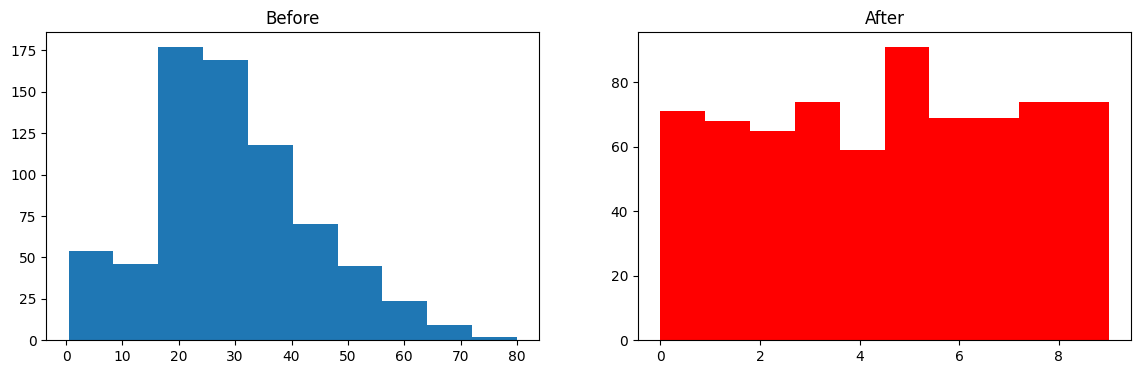

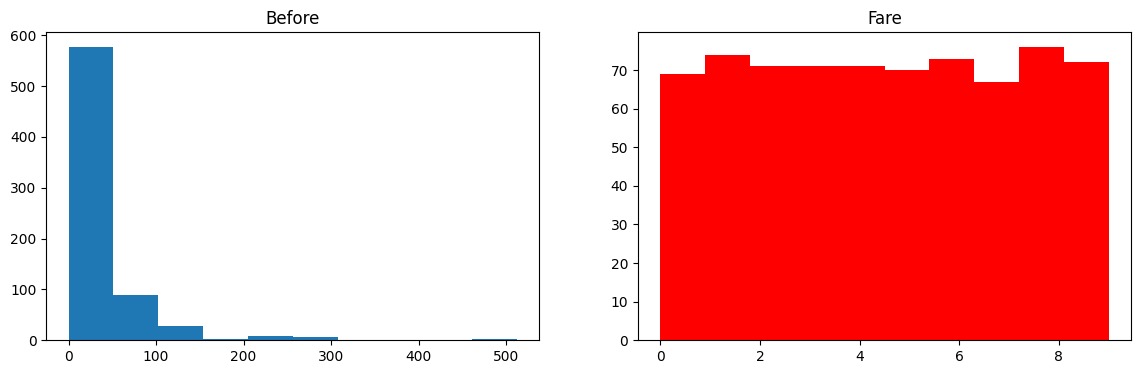

In [114]:
discretize(10,'quantile')